In [1]:
# opening a sample audio file to check sample rate and duration

import librosa
import sys
sys.path.append('..')

from config import DATA_PATH

y, sr = librosa.load(DATA_PATH + '/train/DBA_9863_159.WAV', sr=None)
print(f"Sample rate: {sr}")
print(f"Duration: {len(y)/sr:.4f} seconds")

Sample rate: 250000
Duration: 0.0416 seconds


In [3]:
# getting train-test split breakdown

from pathlib import Path

TRAIN_PATH = Path(DATA_PATH) / "train"
TEST_PATH = Path(DATA_PATH) / "test"

train_files = list(TRAIN_PATH.glob("*.WAV")) + list(TRAIN_PATH.glob("*.wav"))
test_files = list(TEST_PATH.glob("*.WAV")) + list(TEST_PATH.glob("*.wav"))

print(f"Train files: {len(train_files)}")
print(f"Test files: {len(test_files)}")
print(f"Total: {len(train_files) + len(test_files)}")
print(f"Train/test split: {len(train_files)/(len(train_files)+len(test_files))*100:.1f}% / {len(test_files)/(len(train_files)+len(test_files))*100:.1f}%")

Train files: 20265
Test files: 2251
Total: 22516
Train/test split: 90.0% / 10.0%


Matplotlib is building the font cache; this may take a moment.


Min duration:    8.0 ms
Max duration:    409.6 ms
Mean duration:   55.7 ms
Median duration: 46.4 ms


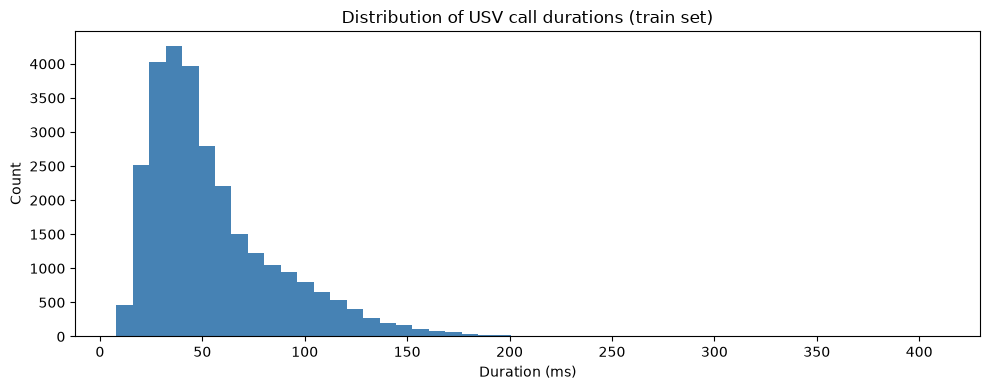

In [ ]:
# analyzing duration distribution of train set

import matplotlib.pyplot as plt
import numpy as np

# compute durations of all train files
durations = []
for f in train_files:
    y, sr = librosa.load(f, sr=None)
    durations.append(len(y) / sr)

durations = np.array(durations)

# print stats
print(f"Min duration:    {durations.min()*1000:.1f} ms")
print(f"Max duration:    {durations.max()*1000:.1f} ms")
print(f"Mean duration:   {durations.mean()*1000:.1f} ms")
print(f"Median duration: {np.median(durations)*1000:.1f} ms")

# make histogram of durations
plt.figure(figsize=(10, 4))
plt.hist(durations * 1000, bins=50, color='steelblue', edgecolor='none')
plt.xlabel("Duration (ms)")
plt.ylabel("Count")
plt.title("Distribution of USV call durations (train set)")
plt.tight_layout()
plt.show()

Min RMS:    0.002372
Max RMS:    0.669853
Mean RMS:   0.046029


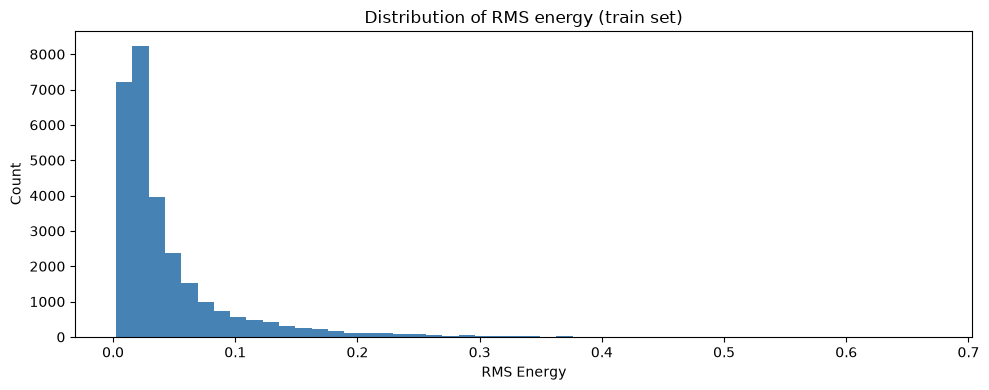


Bottom 5% threshold: 0.007766
Quiet files:
  C57_3535_232.WAV: 0.002372
  C57_3532_170.WAV: 0.002372
  C57_3532_212.WAV: 0.002442
  C57_3532_178.WAV: 0.002467
  C57_3532_171.WAV: 0.002483
  C57_3535_216.WAV: 0.002492
  C57_3532_176.WAV: 0.002518
  C57_3532_177.WAV: 0.002550
  C57_3532_193.WAV: 0.002557
  C57_3532_210.WAV: 0.002569


In [ ]:
# analyzing RMS energy distribution of train set
# rms: root mean square energy, a measure of signal strength (loudness)

# compute RMS energy of all train files
rms_values = []
for f in train_files:
    y, sr = librosa.load(f, sr=None)
    rms = np.sqrt(np.mean(y**2))
    rms_values.append((f.name, rms))

rms_values.sort(key=lambda x: x[1])
rms_array = np.array([r for _, r in rms_values])

# print stats
print(f"Min RMS:    {rms_array.min():.6f}")
print(f"Max RMS:    {rms_array.max():.6f}")
print(f"Mean RMS:   {rms_array.mean():.6f}")

# make figure
plt.figure(figsize=(10, 4))
plt.hist(rms_array, bins=50, color='steelblue', edgecolor='none')
plt.xlabel("RMS Energy")
plt.ylabel("Count")
plt.title("Distribution of RMS energy (train set)")
plt.tight_layout()
plt.show()

# print bottom 5% of RMS values
threshold = np.percentile(rms_array, 5)
print(f"\nBottom 5% threshold: {threshold:.6f}")
print(f"Quiet files:")
for name, rms in rms_values[:10]:
    print(f"  {name}: {rms:.6f}")

In [16]:
c57_rms = [rms for name, rms in rms_values if name.startswith('C57')]
dba_rms = [rms for name, rms in rms_values if name.startswith('DBA')]

print(f"C57 mean RMS: {np.mean(c57_rms):.6f}")
print(f"DBA mean RMS: {np.mean(dba_rms):.6f}")

C57 mean RMS: 0.037512
DBA mean RMS: 0.049418


In [ ]:
c57_test = [f for f in test_files if f.name.startswith('C57')]
dba_test = [f for f in test_files if f.name.startswith('DBA')]

# print(f"Train (C57): {len(c57_files)} | DBA: {len(dba_files)}")
# print(f"Test (C57): {len(c57_test)} | DBA: {len(dba_test)}")
# print(f"Train C57 ratio: {len(c57_files)/(len(c57_files)+len(dba_files))*100:.1f}%")
# print(f"Test  C57 ratio: {len(c57_test)/(len(c57_test)+len(dba_test))*100:.1f}%")

Train — C57: 8064 | DBA: 20265
Test  — C57: 895 | DBA: 2251
Train C57 ratio: 28.5%
Test  C57 ratio: 28.4%


In [ ]:
# getting rid of the C57 strain

import os

c57_train = [f for f in train_files if f.name.startswith('C57')]
c57_test = [f for f in test_files if f.name.startswith('C57')]

for f in c57_train + c57_test:
    os.remove(f)

print(f"Deleted {len(c57_train)} C57 train files")
print(f"Deleted {len(c57_test)} C57 test files")

Deleted 8064 C57 train files
Deleted 895 C57 test files


In [6]:
from pathlib import Path
import soundfile as sf
import pandas as pd

# create a CSV file with the inventory of the train set
# include path, size, duration, and sample rate
rows = []
for p in sorted(TRAIN_PATH.glob("*.WAV")):
    stat = p.stat()
    try:
        info = sf.info(p)
        duration = info.frames / info.samplerate
        sr = info.samplerate
    except Exception:
        duration = None
        sr = None
    rows.append({"path": str(p), "size_bytes": stat.st_size, "duration_s": duration, "sr": sr})
pd.DataFrame(rows).to_csv("eda_train_inventory.csv", index=False)

          size_bytes    duration_s        sr
count   20265.000000  20265.000000   20265.0
mean    28449.372909      0.056811  250000.0
std     15490.651020      0.030981       0.0
min      4046.000000      0.008004  250000.0
25%     17644.000000      0.035200  250000.0
50%     24046.000000      0.048004  250000.0
75%     36046.000000      0.072004  250000.0
max    107246.000000      0.214404  250000.0


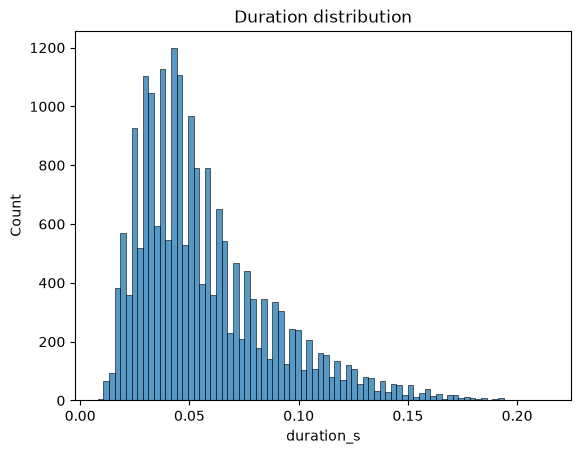

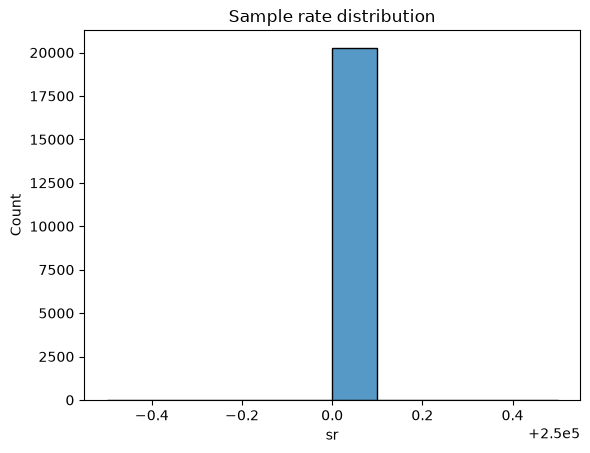

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# analyze the inventory CSV file
df = pd.read_csv("eda_train_inventory.csv")
print(df[["size_bytes","duration_s","sr"]].describe())
sns.histplot(df["duration_s"].dropna(), bins=80)
plt.title("Duration distribution")
plt.show()
sns.histplot(df["sr"].dropna(), bins=10)
plt.title("Sample rate distribution")
plt.show()

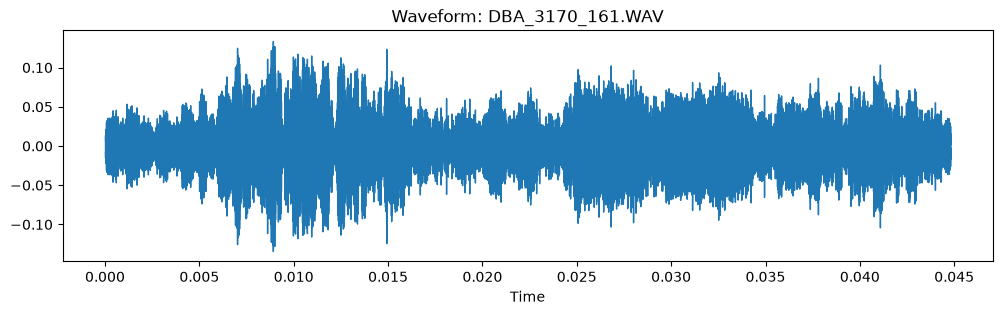

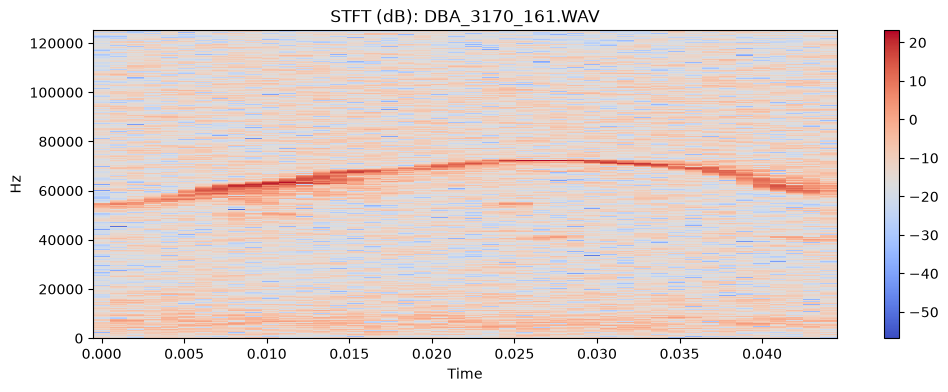

In [9]:
import random, librosa, librosa.display, matplotlib.pyplot as plt
from pathlib import Path

# open a random audio file from the train set and display its waveform
p = random.choice(list(TRAIN_PATH.glob("*.WAV")))
y, sr = librosa.load(p, sr=None)
plt.figure(figsize=(12,3))
librosa.display.waveshow(y, sr=sr)
plt.title(f"Waveform: {p.name}")
plt.show()

# compute and display the STFT (Short-Time Fourier Transform) of the audio signal
D = librosa.stft(y, n_fft=1024, hop_length=256)
S_db = librosa.amplitude_to_db(abs(D))
plt.figure(figsize=(12,4))
librosa.display.specshow(S_db, sr=sr, hop_length=256, x_axis="time", y_axis="hz")
plt.title(f"STFT (dB): {p.name}")
plt.colorbar()
plt.show()